In [1]:
# Task 1 (LO2): Bell state using Cirq and run on Quokka

!pip -q install cirq

import cirq
import numpy as np
from collections import Counter
import requests, json

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 49.0 MB/s eta 0:00:00


In [2]:
def build_bell_circuit():
    q0, q1 = cirq.LineQubit.range(2)
    circuit = cirq.Circuit(
        cirq.H(q0),
        cirq.CNOT(q0, q1),
        cirq.measure(q0, q1, key="m")
    )
    return circuit, (q0, q1)

circuit, qubits = build_bell_circuit()
print("Cirq circuit:\n")
print(circuit)

Cirq circuit:

0: ───H───@───M('m')───
          │   │
1: ───────X───M────────


In [3]:
sim = cirq.Simulator()
shots = 1024

result = sim.run(circuit, repetitions=shots)

bits = result.measurements["m"]  # shape: (shots, 2)
bitstrings = ["".join(map(str, row)) for row in bits]
counts_local = Counter(bitstrings)

print("Local simulation counts:", counts_local)

Local simulation counts: Counter({'11': 522, '00': 502})


In [4]:
try:
    qasm = cirq.qasm(circuit)
    print("Generated QASM (preview):\n")
    print(qasm[:1200])
except Exception as e:
    qasm = None
    print("QASM export failed:", e)

Generated QASM (preview):

// Generated from Cirq v1.6.1

OPENQASM 2.0;
include "qelib1.inc";


// Qubits: [q(0), q(1)]
qreg q[2];
creg m_m[2];


h q[0];
cx q[0],q[1];

// Gate: cirq.MeasurementGate(2, cirq.MeasurementKey(name='m'), ())
measure q[0] -> m_m[0];
measure q[1] -> m_m[1];



In [5]:
QUOKKA_URL = "http://quokka2.quokkacomputing.com/qsim/qasm"
print("Using Quokka URL:", QUOKKA_URL)

Using Quokka URL: http://quokka2.quokkacomputing.com/qsim/qasm


In [6]:
def run_on_quokka(qasm_script: str, shots: int, quokka_url: str):
    payload = {"count": shots, "script": qasm_script}
    headers = {"Content-Type": "application/json"}
    r = requests.post(quokka_url, data=json.dumps(payload), headers=headers, timeout=60)
    r.raise_for_status()
    return r.json()

In [7]:
def quokka_measurements_to_bitstrings(resp, key="m_m"):
    """
    Quokka returns measurements like:
    {'result': {'m_m': [[0,0],[1,1], ...]}}
    Convert them to bitstrings like '00','11'
    """
    raw = resp["result"][key]
    bitstrings = ["".join(str(b) for b in row) for row in raw]
    return bitstrings

In [8]:
if qasm is None:
    print("No QASM generated, skipping Quokka run.")
else:
    shots = 1024

    resp = run_on_quokka(qasm, shots=shots, quokka_url=QUOKKA_URL)

    print("Quokka error:", resp.get("error"))
    print("Quokka error_code:", resp.get("error_code"))

    quokka_bits = quokka_measurements_to_bitstrings(resp, key="m_m")
    counts_quokka = Counter(quokka_bits)

    print("Quokka counts:", counts_quokka)

Quokka error: no error
Quokka error_code: 0
Quokka counts: Counter({'11': 524, '00': 500})


In [9]:
print("\n--- Result comparison ---")
print("Local (Cirq) counts :", counts_local)

try:
    print("Quokka counts       :", counts_quokka)
except:
    print("Quokka counts not available")


--- Result comparison ---
Local (Cirq) counts : Counter({'11': 522, '00': 502})
Quokka counts       : Counter({'11': 524, '00': 500})


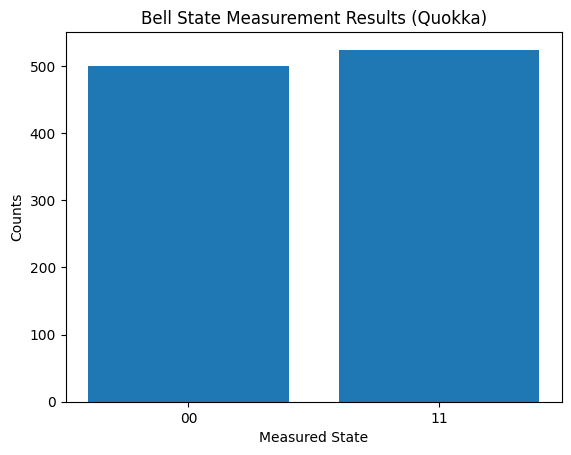

In [11]:
import matplotlib.pyplot as plt

labels = list(counts_quokka.keys())
values = list(counts_quokka.values())

plt.bar(labels, values)
plt.title("Bell State Measurement Results (Quokka)")
plt.xlabel("Measured State")
plt.ylabel("Counts")
plt.show()